In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional but useful
from sklearn.decomposition import PCA

# Plot settings
plt.style.use('default')

In [2]:
# Load datasets
X_ref = np.load("data/raw/X_reference.npy")
y_ref = np.load("data/raw/y_reference.npy")

X_test = np.load("data/raw/X_test.npy")
y_test = np.load("data/raw/y_test.npy")

X_ft = np.load("data/raw/X_finetune.npy")
y_ft = np.load("data/raw/y_finetune.npy")

X_clin18 = np.load("data/raw/X_2018clinical.npy")
y_clin18 = np.load("data/raw/y_2018clinical.npy")

X_clin19 = np.load("data/raw/X_2019clinical.npy")
y_clin19 = np.load("data/raw/y_2019clinical.npy")

print("✅ Data loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/X_reference.npy'

In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
s:\raman-spectral-classifier\notebooks

Files here:
['01_data_understanding.ipynb', '02_domain_analysis.ipynb', '02_domain_analysis_complete.ipynb', '02_preprocessing_qc.ipynb', '03_full_pipeline_results.ipynb', '04_interpretability.ipynb', '05_results_analysis.ipynb', '06_all_data_analysis.ipynb', 'colab_run_finetune.py']


In [4]:
import os

print("Going up one level...\n")

print("Folders in parent directory:")
print(os.listdir(".."))

print("\nChecking data folder:")
print(os.listdir("../data"))

print("\nChecking raw data:")
print(os.listdir("../data/raw"))

Going up one level...

Folders in parent directory:
['.git', '.gitignore', '.pytest_cache', 'analysis_results.md', 'app', 'configs', 'conftest.py', 'data', 'docs', 'experiments', 'FINETUNE_FIX_REPORT.md', 'notebooks', 'pyproject.toml', 'README.md', 'requirements.txt', 'scripts', 'src', 'tests', 'venv', 'whatever', '__pycache__']

Checking data folder:
['processed', 'raw', 'splits']

Checking raw data:
['wavenumbers.npy', 'X_2018clinical.npy', 'X_2019clinical.npy', 'X_finetune.npy', 'X_reference.npy', 'X_test.npy', 'y_2018clinical.npy', 'y_2019clinical.npy', 'y_finetune.npy', 'y_reference.npy', 'y_test.npy']


In [5]:
import numpy as np

base = "../data/raw/"

X_ref = np.load(base + "X_reference.npy")
y_ref = np.load(base + "y_reference.npy")

X_test = np.load(base + "X_test.npy")
y_test = np.load(base + "y_test.npy")

X_ft = np.load(base + "X_finetune.npy")
y_ft = np.load(base + "y_finetune.npy")

X_clin18 = np.load(base + "X_2018clinical.npy")
y_clin18 = np.load(base + "y_2018clinical.npy")

X_clin19 = np.load(base + "X_2019clinical.npy")
y_clin19 = np.load(base + "y_2019clinical.npy")

print("✅ All datasets loaded")

✅ All datasets loaded


In [6]:
def summarize(name, X, y):
    print(f"\n{name}")
    print("-" * 50)
    print("Shape:", X.shape)
    print("Min / Max:", X.min(), X.max())
    print("Mean / Std:", X.mean(), X.std())
    print("Unique labels:", np.unique(y))
    print("Num classes:", len(np.unique(y)))

summarize("REFERENCE", X_ref, y_ref)
summarize("TEST", X_test, y_test)
summarize("FINETUNE", X_ft, y_ft)
summarize("CLINICAL 2018", X_clin18, y_clin18)
summarize("CLINICAL 2019", X_clin19, y_clin19)


REFERENCE
--------------------------------------------------
Shape: (60000, 1000)
Min / Max: 0.0 1.0
Mean / Std: 0.4276437380614325 0.18074481364096925
Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Num classes: 30

TEST
--------------------------------------------------
Shape: (3000, 1000)
Min / Max: 0.0 1.0
Mean / Std: 0.42513455845384907 0.16914480656948747
Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Num classes: 30

FINETUNE
--------------------------------------------------
Shape: (3000, 1000)
Min / Max: 0.0 1.0
Mean / Std: 0.4240386026634618 0.17087871691787343
Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Num classes: 30

CLINICAL 2018
--------------------------------------------------
Shape: (10000, 1000)

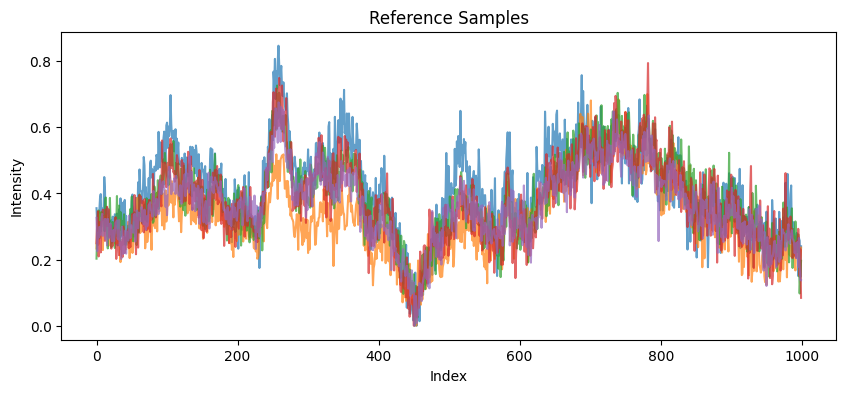

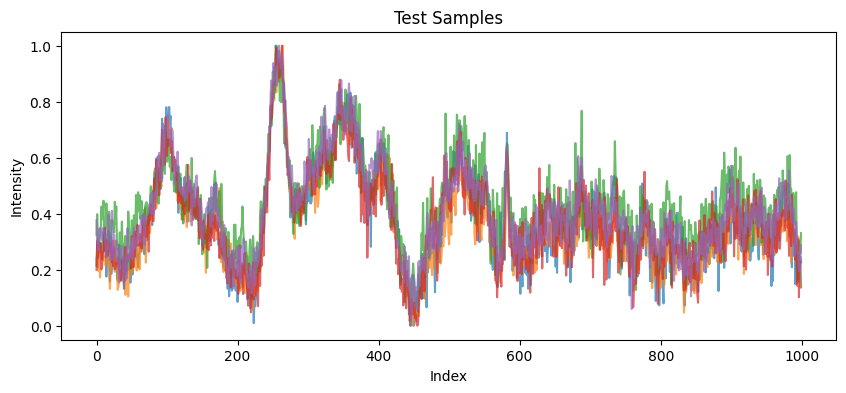

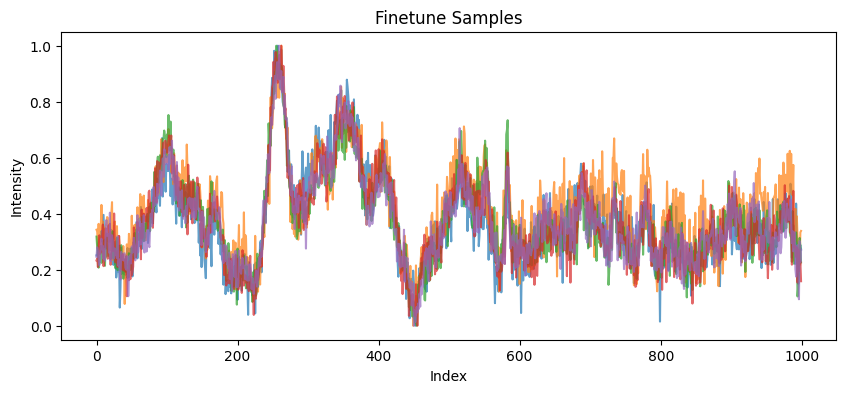

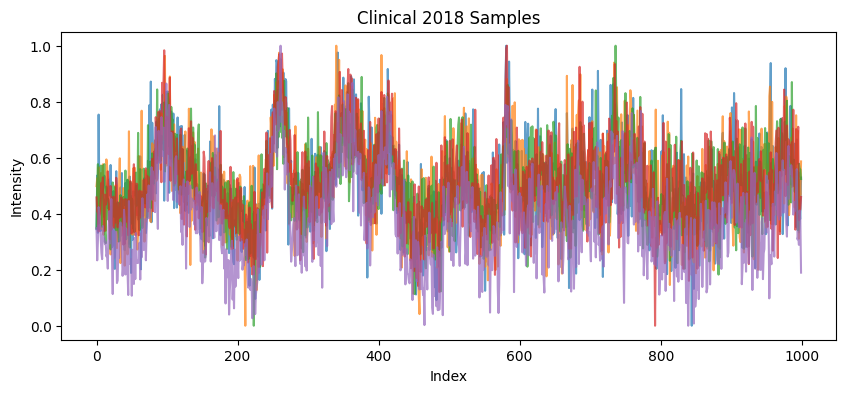

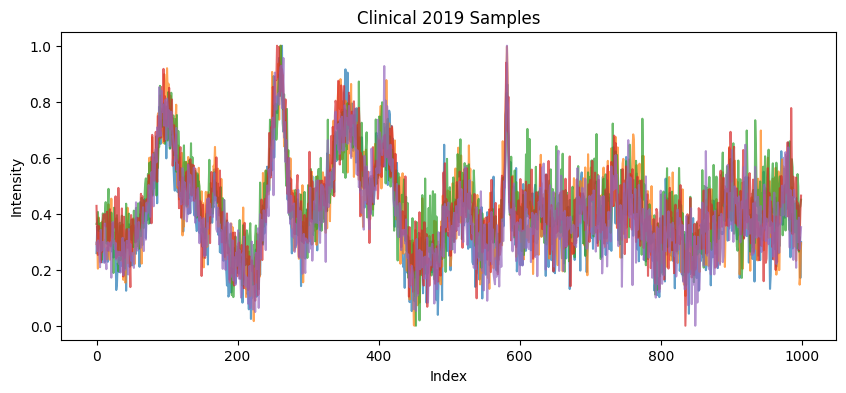

In [7]:
def plot_samples(X, title, n=5):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.plot(X[i], alpha=0.7)
    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("Intensity")
    plt.show()

plot_samples(X_ref, "Reference Samples")
plot_samples(X_test, "Test Samples")
plot_samples(X_ft, "Finetune Samples")
plot_samples(X_clin18, "Clinical 2018 Samples")
plot_samples(X_clin19, "Clinical 2019 Samples")

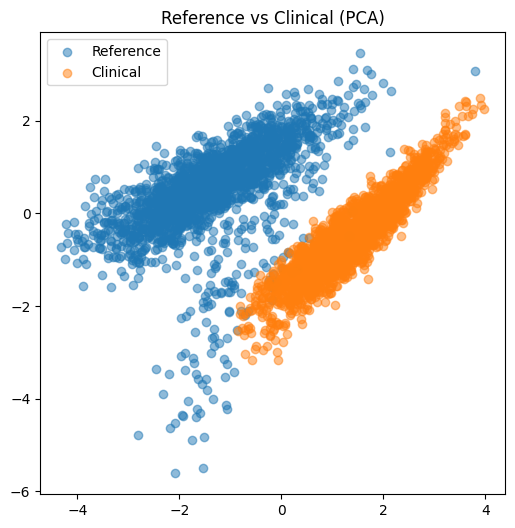

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Sample smaller subset for speed
n = 2000

X_combined = np.concatenate([
    X_ref[:n],
    X_clin18[:n]
])

labels = np.array([0]*n + [1]*n)  # 0 = reference, 1 = clinical

X_flat = X_combined.reshape(len(X_combined), -1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:n,0], X_pca[:n,1], label="Reference", alpha=0.5)
plt.scatter(X_pca[n:,0], X_pca[n:,1], label="Clinical", alpha=0.5)

plt.legend()
plt.title("Reference vs Clinical (PCA)")
plt.show()

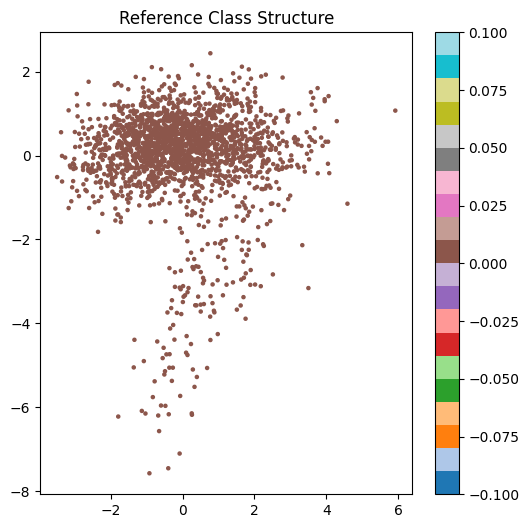

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca_classes(X, y, title, n_samples=2000):
    X_small = X[:n_samples]
    y_small = y[:n_samples]

    X_flat = X_small.reshape(len(X_small), -1)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_flat)

    plt.figure(figsize=(6,6))
    scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_small, cmap='tab20', s=5)
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_pca_classes(X_ref, y_ref, "Reference Class Structure")

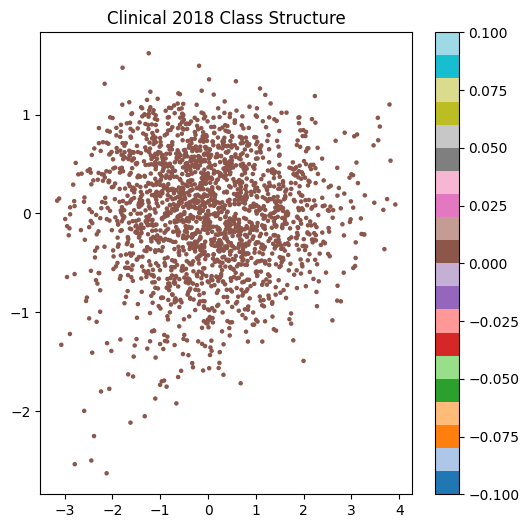

In [10]:
plot_pca_classes(X_clin18, y_clin18, "Clinical 2018 Class Structure")